# DO Masked Card Classifier Training

Train a dedicated card-label classifier that uses card masks as input guidance.

This notebook uses a 4-stage curriculum designed to improve precision without making training unnecessarily slow:
1. Stage 1: short warm-up on clean reference card crops.
2. Stage 2: train on generated augmented-card crops with saved augmented-card masks (photometric-only single-card generation).
3. Stage 3: fine-tune on augmented-scene card crops using manual scene masks.
4. Stage 4: refine on augmented-scene card crops using masks predicted by the scene segmenter.

## Pipeline conventions and storage

- Only challenge data from this workspace is used.
- No pretrained weights are loaded (`torchvision` models use `weights=None`).
- Model parameter count is asserted to be <= 12M.
- Segmenter masks are used as supervision/input for classification preprocessing, not as a second prediction target.
- Single-card augmentation is photometric-only (contrast/exposure/noise). Rotation/overlap robustness is learned in scene-mask stages.
- Training uses balanced sampling and capped augmented-card epochs so useful classes are seen often without cycling through every generated crop each epoch.
- Data sources:
  - `project/training_data/object_labels/reference_cards/reference_do.csv`
  - `project/training_data/object_labels/augmented_cards/aug.csv`
  - `project/training_data/object_labels/augmented_scenes/labels.json`
  - `project/training_data/training_images/reference_cards/`
  - `project/training_data/training_images/augmented_cards/`
  - `project/training_data/training_masks/augmented_cards/`
  - `project/training_data/training_images/augmented_scenes/`
  - `project/training_data/training_masks/augmented_scenes/`
- Model artifacts are written to `project/models/`.

In [ ]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd() / "project" / "notebooks" / "do" / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.train_classifier_CNN import (
    TrainPipelineConfig,
    initialize_training_pipeline,
    plot_stage_preview,
    plot_wrong_predictions,
    run_training,
    run_validation_diagnostics,
    save_training_artifacts,
)

# Most-used quick knobs
SEED = 42
IMG_SIZE = 160
SEGMENTER_IMG_SIZE = 256
BBOX_MARGIN = 0.08
MASK_THRESHOLD = 0.50
VAL_SPLIT = 0.20

STAGE_1_EPOCHS = 0
STAGE_2_EPOCHS = 2
STAGE_3_EPOCHS = 10
STAGE_4_EPOCHS = 10

STAGE_1_LR = 1e-3
STAGE_2_LR = 1e-3
STAGE_3_LR = 3e-4
STAGE_4_LR = 2e-4

WEIGHT_DECAY = 1e-4
BALANCED_SAMPLING = True
EARLY_STOP_PATIENCE = 3
MIN_EPOCHS_PER_STAGE = 2
EPOCH_MAX_TRAIN_SAMPLES = None

TRAIN_CFG = TrainPipelineConfig(
    seed=SEED,
    img_size=IMG_SIZE,
    segmenter_img_size=SEGMENTER_IMG_SIZE,
    bbox_margin=BBOX_MARGIN,
    mask_threshold=MASK_THRESHOLD,
    val_split=VAL_SPLIT,
    stage_1_epochs=STAGE_1_EPOCHS,
    stage_2_epochs=STAGE_2_EPOCHS,
    stage_3_epochs=STAGE_3_EPOCHS,
    stage_4_epochs=STAGE_4_EPOCHS,
    stage_1_lr=STAGE_1_LR,
    stage_2_lr=STAGE_2_LR,
    stage_3_lr=STAGE_3_LR,
    stage_4_lr=STAGE_4_LR,
    weight_decay=WEIGHT_DECAY,
    balanced_sampling=BALANCED_SAMPLING,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_epochs_per_stage=MIN_EPOCHS_PER_STAGE,
    epoch_max_train_samples=EPOCH_MAX_TRAIN_SAMPLES,
)

TRAIN_CFG

TrainPipelineConfig(seed=42, img_size=160, segmenter_img_size=256, bbox_margin=0.08, mask_threshold=0.5, val_split=0.2, stage_1_epochs=0, stage_2_epochs=15, stage_3_epochs=10, stage_4_epochs=10, stage_1_lr=0.001, stage_2_lr=0.001, stage_3_lr=0.0003, stage_4_lr=0.0002, weight_decay=0.0001, label_smoothing=0.05, balanced_sampling=True, early_stop_patience=3, min_epochs_per_stage=2, epoch_max_train_samples=None, batch_size_cuda=32, batch_size_mps=16, batch_size_cpu=8, num_workers=0, reference_target_gpu_mps=1536, reference_target_cpu=512, augmented_target_gpu_mps=4096, augmented_target_cpu=1536, scene_target_gpu_mps=4096, scene_target_cpu=1536, scene_finetune_freeze_bn_stats=True, grad_clip_norm=1.0, preview_per_stage=3)

## Classification Pipeline Building Blocks

This section defines:
- data loading and crop/mask preparation,
- scene-segmenter inference helper used to produce predicted masks for stage 3,
- a classification-specific backbone (ResNet18, random init),
- dataset and training utilities.

Design choices:
- input card size is fixed with letterboxing,
- the classifier consumes RGB + binary mask as a 4-channel tensor,
- the objective is classification-only (cross-entropy),
- segmenter masks are used for preprocessing/input guidance, not as an auxiliary prediction head.

In [2]:
train_state = initialize_training_pipeline(TRAIN_CFG)
train_state.keys()

Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Training data: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data
Model output dir: /Users/dorianbesson/EDOC/IA/iapr2026do/project/models
Device: mps
Augmented-card masks: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_masks/augmented_cards
[compliance] SceneUNetSmall: 1,928,417 trainable params
Building predicted scene masks for 4000 scenes...
  100/4000
  200/4000
  300/4000
  400/4000
  500/4000
  600/4000
  700/4000
  800/4000
  900/4000
  1000/4000
  1100/4000
  1200/4000
  1300/4000
  1400/4000
  1500/4000
  1600/4000
  1700/4000
  1800/4000
  1900/4000
  2000/4000
  2100/4000
  2200/4000
  2300/4000
  2400/4000
  2500/4000
  2600/4000
  2700/4000
  2800/4000
  2900/4000
  3000/4000
  3100/4000
  3200/4000
  3300/4000
  3400/4000
  3500/4000
  3600/4000
  3700/4000
  3800/4000
  3900/4000
  4000/4000
[compliance] CardResNet18Classifier: 11,207,350 trainable params
Reference samples:           54

dict_keys(['config', 'project_root', 'project_dir', 'training_data', 'models_dir', 'device', 'use_amp', 'batch_size', 'norm_mean', 'norm_std', 'card_model_path', 'card_classes_path', 'card_config_path', 'scene_segmenter_path', 'reference_samples', 'augmented_card_samples', 'scene_manual_samples', 'scene_train_samples', 'scene_val_samples', 'scene_predicted_train_samples', 'scene_predicted_val_samples', 'predicted_scene_probs', 'label_encoder', 'label_to_index', 'reference_samples_per_epoch', 'augmented_samples_per_epoch', 'scene_manual_samples_per_epoch', 'scene_predicted_samples_per_epoch', 'train_loader_ref', 'train_loader_augmented', 'train_loader_manual', 'train_loader_predicted', 'val_loader', 'val_loader_predicted', 'model', 'model_params', 'ce_loss', 'scaler', 'history', 'best_val_acc', 'best_stage', 'best_epoch', 'training_seconds'])

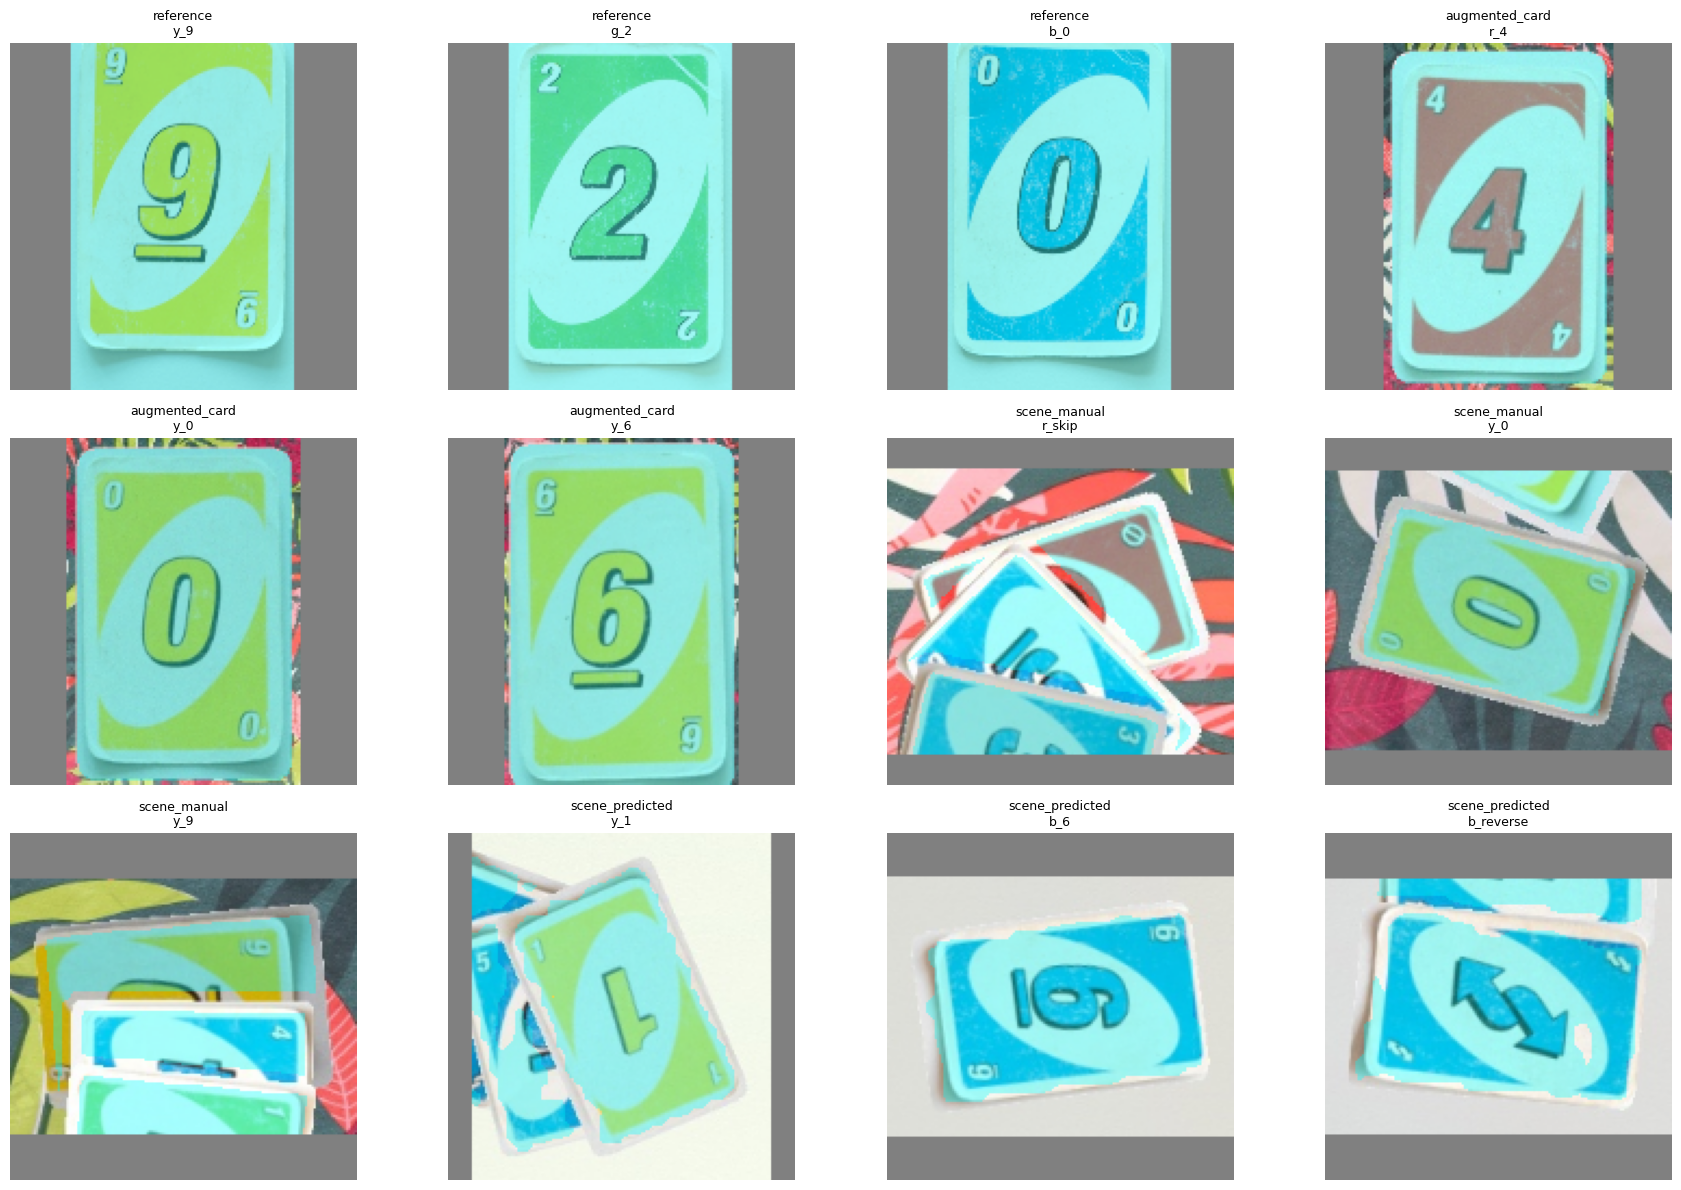

In [3]:
plot_stage_preview(train_state, per_stage=TRAIN_CFG.preview_per_stage)

## Build Stage Datasets

We build four sample groups:
- `reference`: clean card crops from reference labels.
- `augmented_card`: generated single-card crops + saved augmented-card masks (photometric-only augmentation).
- `scene_manual`: scene card crops + manual scene masks.
- `scene_predicted`: scene card crops + masks from the trained scene segmenter.

Validation is held out from `scene_manual` only and reused for all training stages, because those crops are closest to the final scene-classification problem while still having trusted labels and masks.

In [4]:
train_state = run_training(train_state)
train_state = save_training_artifacts(train_state)
{
    "best_stage": train_state.get("best_stage"),
    "best_epoch": train_state.get("best_epoch"),
    "best_val_acc": train_state.get("best_val_acc"),
    "training_seconds": train_state.get("training_seconds"),
}

[skip] stage1_reference: no epochs or no samples

[stage2_augmented_cards] epochs=15, lr=1.00e-03, dataset_samples=21600, samples_per_epoch=4096
  per-epoch cap active: epochs cycle through the full stage sample pool before repeating
  epoch 01/15 | train_acc= 45.2% loss=2.120 | val(manual)= 11.0% val(pred)= 10.9% | lr=1.00e-03 | 103.8s | stage-best
  epoch 02/15 | train_acc= 91.0% loss=0.798 | val(manual)= 23.5% val(pred)= 22.8% | lr=1.00e-03 | 100.6s | stage-best
  epoch 03/15 | train_acc= 96.8% loss=0.609 | val(manual)= 19.1% val(pred)= 19.0% | lr=1.00e-03 | 99.8s
  epoch 04/15 | train_acc= 98.4% loss=0.529 | val(manual)= 16.4% val(pred)= 16.4% | lr=1.00e-03 | 98.8s
  epoch 05/15 | train_acc= 99.3% loss=0.480 | val(manual)= 23.5% val(pred)= 23.7% | lr=5.00e-04 | 97.3s
  epoch 06/15 | train_acc= 99.9% loss=0.444 | val(manual)= 22.0% val(pred)= 21.8% | lr=5.00e-04 | 97.1s
  epoch 07/15 | train_acc= 99.9% loss=0.434 | val(manual)= 24.3% val(pred)= 24.2% | lr=5.00e-04 | 98.0s | stage-be

{'best_stage': 'stage4_scene_predicted_masks',
 'best_epoch': 9,
 'best_val_acc': 0.8809924305638313,
 'training_seconds': 3736.5694447080023}

Validation accuracy (manual masks): 88.14%
              precision    recall  f1-score   support

         b_0       0.85      0.91      0.88       149
         b_1       0.95      0.94      0.94       125
         b_2       0.92      0.81      0.86       132
         b_3       0.89      0.86      0.87       147
         b_4       0.76      0.92      0.83       157
         b_5       0.89      0.83      0.86       137
         b_6       0.94      0.79      0.86       126
         b_7       0.81      0.89      0.85       124
         b_8       0.86      0.86      0.86       139
         b_9       0.85      0.89      0.87       144
    b_draw_2       0.90      0.93      0.92       135
   b_reverse       0.86      0.92      0.89       142
      b_skip       0.98      0.90      0.94       145
      draw_4       0.88      0.96      0.92       137
         g_0       0.82      0.93      0.88       150
         g_1       0.94      0.86      0.90       139
         g_2       0.90      0.91     

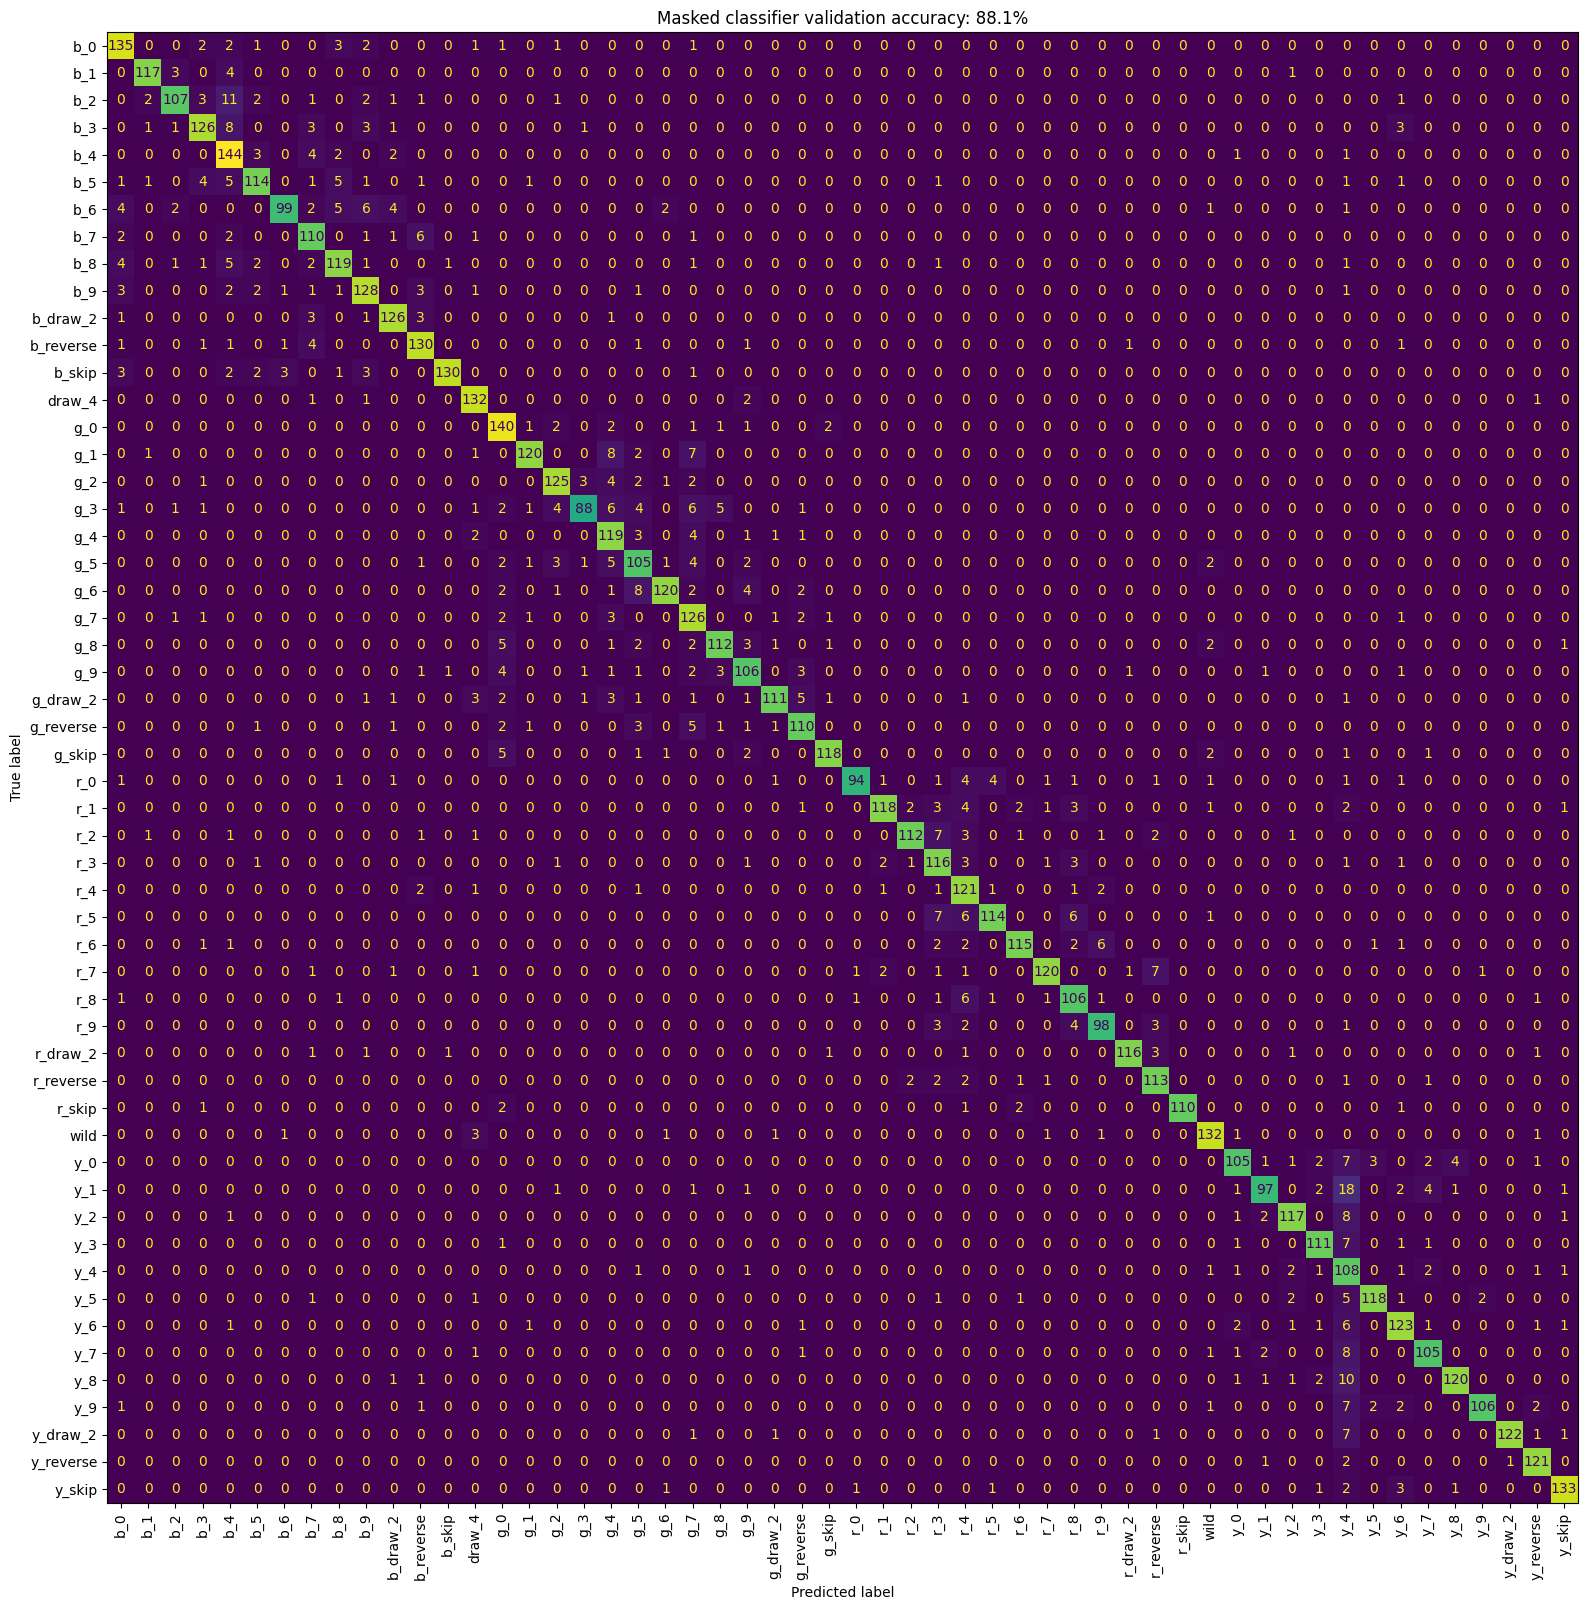

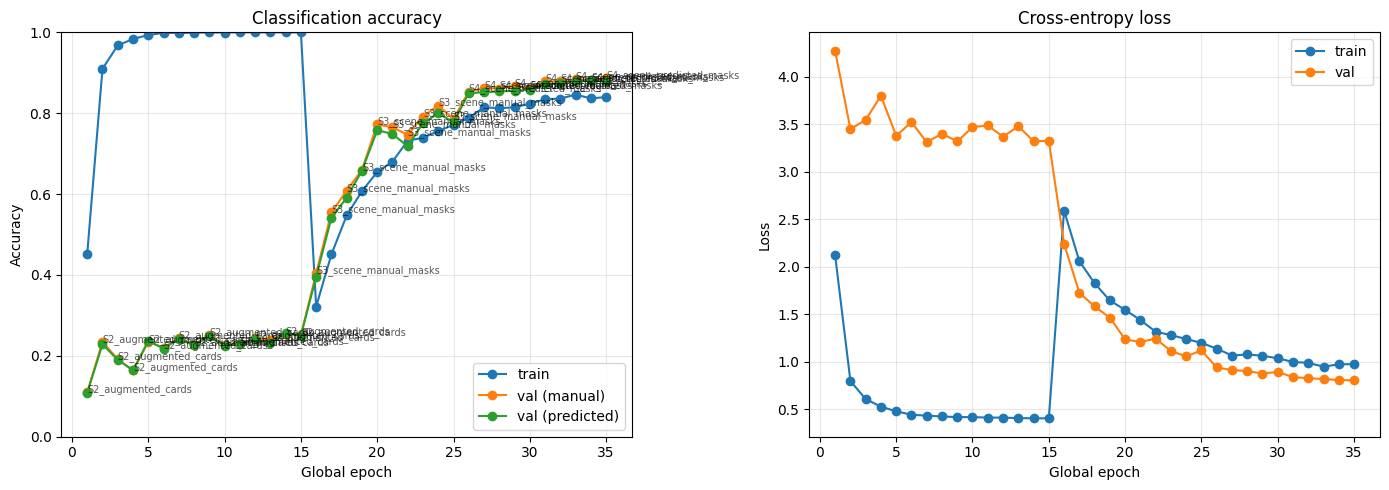

{'loss': 0.8095883133199524,
 'cls_acc': 0.881412952010425,
 'skipped_non_finite_batches': 0.0}

In [5]:
train_state = run_validation_diagnostics(train_state)
train_state.get("val_metrics", {})

In [6]:
# # repair_validation_diagnostics removed in refactor; run_validation_diagnostics now produces aligned arrays directly.
# {
#     "rows": int(len(train_state.get("val_true_idx", []))),
#     "n_true_classes": int(len(set(train_state.get("true_labels", [])))),
#     "n_pred_classes": int(len(set(train_state.get("pred_labels", [])))),
# }

## Stage Training (Reference -> Augmented Cards -> Manual Masks -> Predicted Masks)

The classifier is trained sequentially with the same weights carried across stages:
1. bootstrap on clean references,
2. learn photometric variation from generated augmented card crops and their masks,
3. adapt to scene crops (including overlap/rotation effects) with manual masks,
4. refine against predicted-mask noise from the segmenter.

Validation is always computed on held-out manual-scene samples.

Training-speed changes:
- class-balanced sampling keeps rare labels visible during each stage,
- every stage now uses an explicit, batch-aligned `samples_per_epoch` budget,
- later stages can stop early when validation accuracy plateaus.

Checkpoint selection policy:
- best-epoch selection is stage-local for the latest stage only,
- earlier stages are treated as curriculum warm-up and are not candidates for the final checkpoint.

Loss: classification-only cross-entropy.

Wrong validation predictions: 846 / 7134


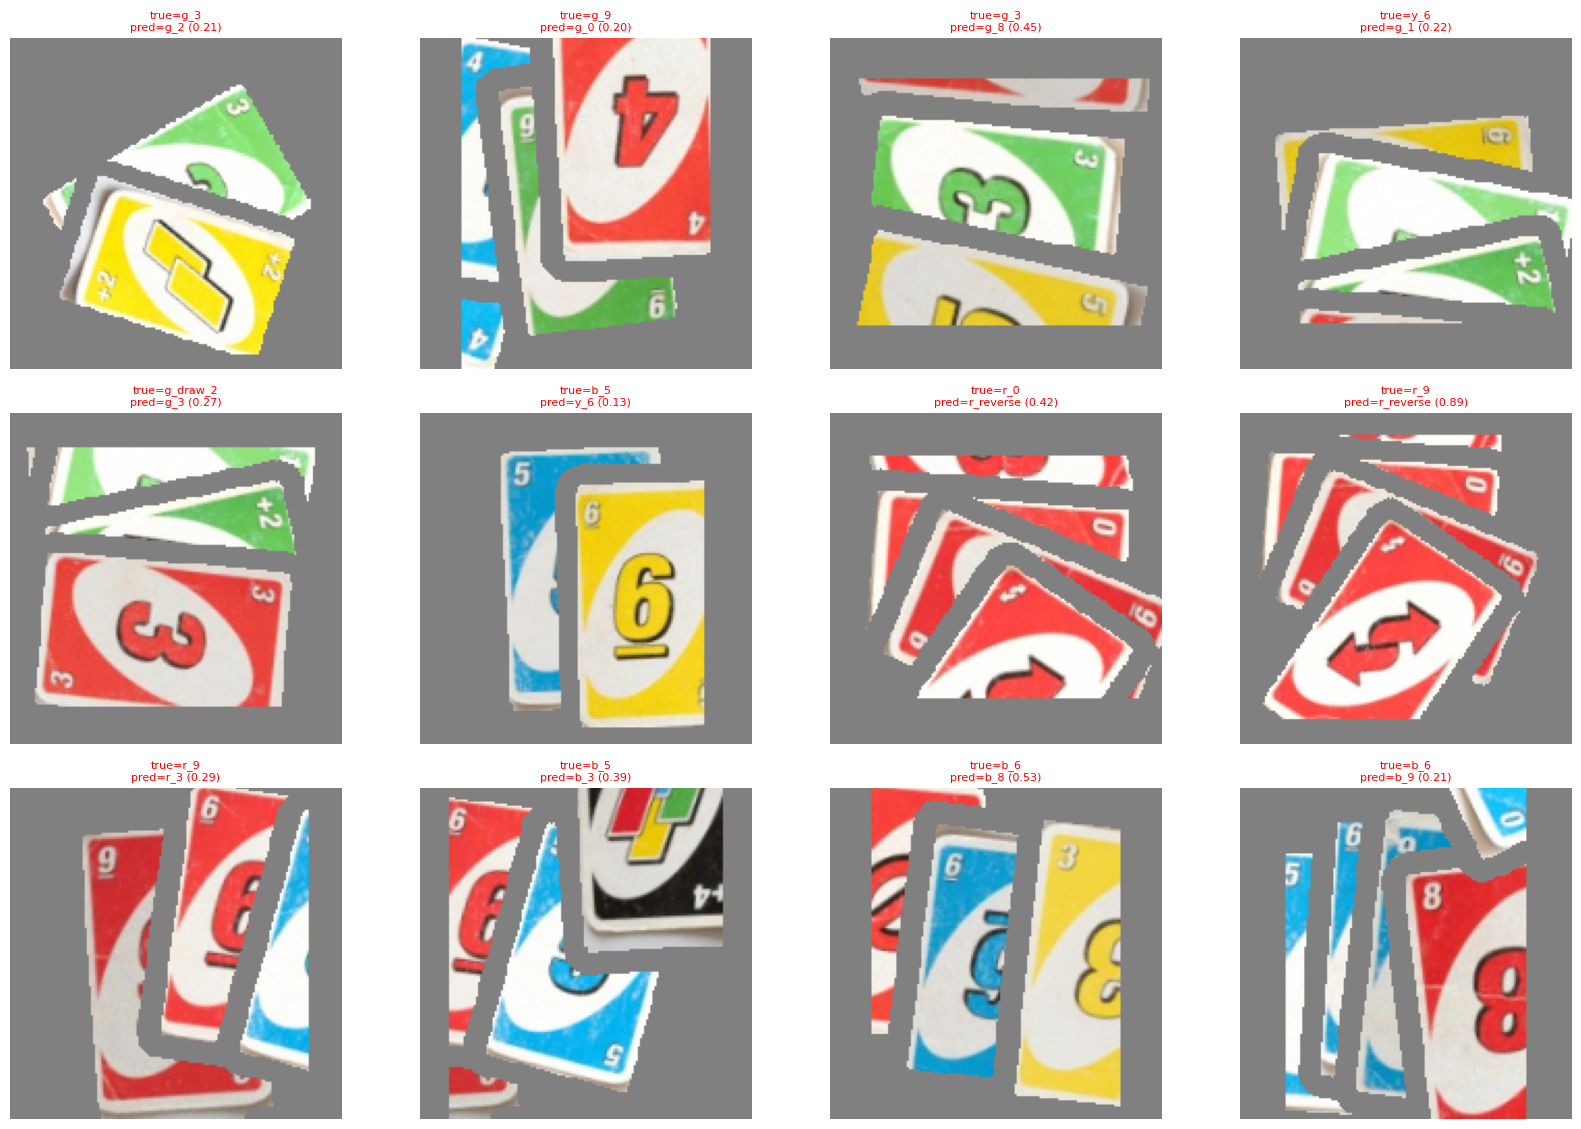

846

In [7]:
wrong_indices = plot_wrong_predictions(train_state, show_count=12)
len(wrong_indices)

## Validation Diagnostics

We evaluate the best checkpoint on the held-out manual-scene validation set.

Reported diagnostics:
- classification report and confusion matrix,
- stage-wise learning curves (accuracy and loss),
- qualitative errors with mask-guided classifier input overlays.

In [8]:
train_state.get("saved_config", {}).get("stage_plan", [])

[{'stage': 'stage1_reference',
  'epochs': 0,
  'learning_rate': 0.001,
  'n_samples': 54,
  'samples_per_epoch': 48},
 {'stage': 'stage2_augmented_cards',
  'epochs': 15,
  'learning_rate': 0.001,
  'n_samples': 21600,
  'samples_per_epoch': 4096},
 {'stage': 'stage3_scene_manual_masks',
  'epochs': 10,
  'learning_rate': 0.0003,
  'n_samples': 28723,
  'samples_per_epoch': 4096},
 {'stage': 'stage4_scene_predicted_masks',
  'epochs': 10,
  'learning_rate': 0.0002,
  'n_samples': 28723,
  'samples_per_epoch': 4096}]

In [9]:
train_state["label_encoder"].classes_[:20]

array(['b_0', 'b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'b_6', 'b_7', 'b_8',
       'b_9', 'b_draw_2', 'b_reverse', 'b_skip', 'draw_4', 'g_0', 'g_1',
       'g_2', 'g_3', 'g_4', 'g_5'], dtype='<U9')

In [10]:
train_state.get("history", [])[-5:]

[{'stage': 'stage4_scene_predicted_masks',
  'epoch': 6,
  'train_loss': 0.9995330165838823,
  'train_cls_acc': 0.83447265625,
  'val_loss': 0.8393488506125174,
  'val_cls_acc': 0.8786094756997999,
  'val_pred_loss': 0.8540997056523926,
  'val_pred_cls_acc': 0.8713204373590144,
  'lr': 0.0002,
  'seconds': 107.83806724999886,
  'samples_per_epoch': 4096,
  'train_skipped_non_finite_batches': 0,
  'val_skipped_non_finite_batches': 0},
 {'stage': 'stage4_scene_predicted_masks',
  'epoch': 7,
  'train_loss': 0.9896174973109737,
  'train_cls_acc': 0.836181640625,
  'val_loss': 0.8286276623285014,
  'val_cls_acc': 0.8793103447774562,
  'val_pred_loss': 0.8423465250385286,
  'val_pred_cls_acc': 0.8742640874183308,
  'lr': 0.0002,
  'seconds': 107.88998191699648,
  'samples_per_epoch': 4096,
  'train_skipped_non_finite_batches': 0,
  'val_skipped_non_finite_batches': 0},
 {'stage': 'stage4_scene_predicted_masks',
  'epoch': 8,
  'train_loss': 0.9495774019742385,
  'train_cls_acc': 0.845947265

In [11]:
# # Optional convenience rerun if you changed the model in memory.
# train_state = run_validation_diagnostics(train_state)
# train_state.get("val_metrics", {})